# LSTM Stock Price Prediction

- LSTM -> Long Short Term Memory

## Requirements

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import root_mean_squared_error
from torch.utils.data import Dataset
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
import numpy as np
import ipynbname
import matplotlib.pyplot as plt


## Tutorials
- **(Greg Hogg, 2023)** Video: https://www.youtube.com/watch?v=q_HS4s1L8UI&t=147s
- **(NeuralNine, 2025)** Video: https://www.youtube.com/watch?v=IJ50ew8wi-0

## Load Data

In [2]:
df = pd.read_csv('../data/combined_output.csv')

df.head()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,...,previous_day_high,previous_day_low,previous_day_open,previous_day_volume,day_of_week,numerical_sentiment,mean_sentiment_probability,percent_positive,percent_negative,percent_neutral
0,2026-01-28,668.73,677.6775,666.1000,674.50,25709600,668.170928,677.110948,665.543127,673.936104,...,676.8150,664.6600,674.59,13148719.0,3,0.170543,0.801010,0.302326,0.131783,0.565891
1,2026-01-29,738.31,744.0000,712.5500,737.43,59852903,737.692758,743.378001,711.954294,736.813493,...,677.6775,666.1000,674.50,25709600.0,4,-0.027027,0.806134,0.209459,0.236486,0.554054
2,2026-01-30,716.50,732.1700,713.5900,727.50,23744573,715.900991,731.557891,712.993424,726.891795,...,744.0000,712.5500,737.43,59852903.0,5,-0.109375,0.837781,0.156250,0.265625,0.578125
3,2026-02-02,706.41,721.3000,703.5201,714.60,14365224,705.819427,720.696978,702.931943,714.002580,...,732.1700,713.5900,727.50,23744573.0,1,-0.076923,0.814024,0.153846,0.230769,0.615385
4,2026-02-03,691.70,717.0000,686.4100,707.37,13512258,691.121725,716.400573,685.836147,706.778624,...,721.3000,703.5201,714.60,14365224.0,2,-0.096154,0.798190,0.076923,0.173077,0.750000


## Check Device

In [3]:
def get_device():
    return 'cuda:0' if torch.cuda.is_available() else 'cpu:1'

device = get_device()

device

'cpu:1'

## Lag Features

In [4]:
def create_features(df):
    day = 1
    df = df.set_index('date')
    df['previous_day_numerical_sentiment'] = df['numerical_sentiment'].shift(day)
    df['previous_day_mean_sentiment_probability'] = df['mean_sentiment_probability'].shift(day)
    df['previous_day_percent_positive'] = df['percent_positive'].shift(day)
    df['previous_day_percent_negative'] = df['percent_negative'].shift(day)
    df['previous_day_percent_neutral'] = df['percent_neutral'].shift(day)
    df = df.drop(columns=['high',
                          'low',
                          'open',
                          'volume',
                          'adjClose',
                          'adjHigh',
                          'adjLow',
                          'adjOpen',
                          'adjVolume',
                          'divCash',
                          'splitFactor',
                          'numerical_sentiment',
                          'mean_sentiment_probability',
                          'percent_positive',
                          'percent_negative',
                          'percent_neutral',])
    return df

df = create_features(df)

df.iloc[0]

close                                      6.687300e+02
previous_day_close                         6.729700e+02
previous_day_high                          6.768150e+02
previous_day_low                           6.646600e+02
previous_day_open                          6.745900e+02
previous_day_volume                        1.314872e+07
day_of_week                                3.000000e+00
previous_day_numerical_sentiment                    NaN
previous_day_mean_sentiment_probability             NaN
previous_day_percent_positive                       NaN
previous_day_percent_negative                       NaN
previous_day_percent_neutral                        NaN
Name: 2026-01-28, dtype: float64

## Plot

[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Closing Price')]

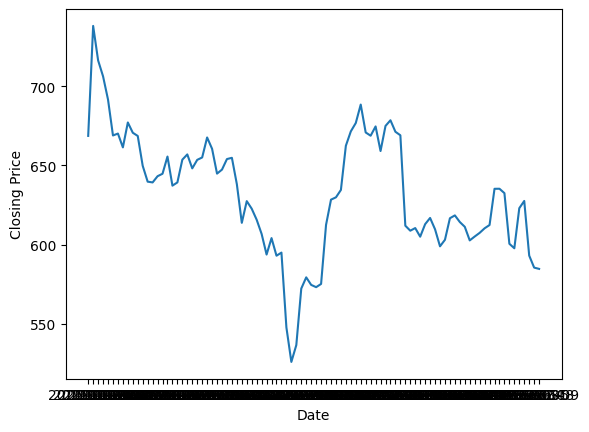

In [5]:
line_graph = sns.lineplot(x='date', y='close', data=df)
line_graph.set(xlabel='Date', ylabel='Closing Price')

## Remove Rows With Nulls

In [6]:
def remove_nulls(df, called_externally=False):
    df = df.dropna()
    prefix = ''
    # Allows function to be run within notebook or when called by external files

    if not called_externally:
        prefix = '../'

    file_name = f'{prefix}data/model_ready.csv'
    df.to_csv(file_name)
    return df

df = remove_nulls(df)
df.iloc[0]

close                                      7.383100e+02
previous_day_close                         6.687300e+02
previous_day_high                          6.776775e+02
previous_day_low                           6.661000e+02
previous_day_open                          6.745000e+02
previous_day_volume                        2.570960e+07
day_of_week                                4.000000e+00
previous_day_numerical_sentiment           1.705426e-01
previous_day_mean_sentiment_probability    8.010101e-01
previous_day_percent_positive              3.023256e-01
previous_day_percent_negative              1.317829e-01
previous_day_percent_neutral               5.658915e-01
Name: 2026-01-29, dtype: float64

## Scale Data

In [7]:
def scale_data(df, train_decimal=0.7):
    # Initialise scalars
    scalar_x = StandardScaler()
    scalar_y = StandardScaler()

    X_df = df.iloc[:,1:]
    Y_df = df.iloc[:, [0]]

    train_size = int(len(df) * train_decimal)

    X_train_df_as_numpy = scalar_x.fit_transform(X_df[:train_size]) # Fit to training data
    Y_train_df_as_numpy = scalar_y.fit_transform(Y_df[:train_size]) # Don't fit to test data as it will cause data leakage
    # This condition allows all data to be used for training when users ask for same day predictions
    if train_decimal < 1:
        X_test_df_as_numpy = scalar_x.transform(X_df[train_size:])
        Y_test_df_as_numpy = scalar_y.transform(Y_df[train_size:])
    else:
        X_test_df_as_numpy = None
        Y_test_df_as_numpy = None

    return X_train_df_as_numpy, X_test_df_as_numpy, Y_train_df_as_numpy, Y_test_df_as_numpy, scalar_x, scalar_y

X_train_df_as_numpy, X_test_df_as_numpy, Y_train_df_as_numpy, Y_test_df_as_numpy, scalar_x, scalar_y = scale_data(df)

X_train_df_as_numpy.shape, X_test_df_as_numpy.shape, Y_train_df_as_numpy.shape, Y_test_df_as_numpy.shape

((63, 11), (28, 11), (63, 1), (28, 1))

## Split Data Train/Test

In [8]:
def split_data(X_train_df_as_numpy, X_test_df_as_numpy, Y_train_df_as_numpy, Y_test_df_as_numpy):
    # PyTorch LSTMs require 3-dimensional input
    X_train = X_train_df_as_numpy.reshape((-1, 11, 1))
    Y_train = Y_train_df_as_numpy.reshape((-1, 1))

    if type(X_test_df_as_numpy) == np.ndarray:
        X_test = X_test_df_as_numpy.reshape((-1, 11, 1))
        Y_test = Y_test_df_as_numpy.reshape((-1, 1))
    else:
        X_test = X_test_df_as_numpy
        Y_test = Y_test_df_as_numpy

    return X_train, X_test, Y_train, Y_test

X_train, X_test, Y_train, Y_test = split_data(X_train_df_as_numpy, X_test_df_as_numpy, Y_train_df_as_numpy, Y_test_df_as_numpy)

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((63, 11, 1), (63, 1), (28, 11, 1), (28, 1))

## Convert To Tensors

In [9]:
def convert_to_tensors(X_train, X_test, Y_train, Y_test):
    X_train = torch.tensor(X_train).float()
    Y_train = torch.tensor(Y_train).float()
    if type(X_test) == np.ndarray:
        X_test = torch.tensor(X_test).float()
        Y_test = torch.tensor(Y_test).float()

    return X_train, X_test, Y_train, Y_test

X_train, X_test, Y_train, Y_test = convert_to_tensors(X_train, X_test, Y_train, Y_test)

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

(torch.Size([63, 11, 1]),
 torch.Size([63, 1]),
 torch.Size([28, 11, 1]),
 torch.Size([28, 1]))

## Dataset Class

In [10]:
class StockDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [11]:
def create_datasets(X_train, X_test, Y_train, Y_test):
    train_dataset = StockDataset(X_train, Y_train)
    test_dataset = StockDataset(X_test, Y_test)

    return train_dataset, test_dataset

train_dataset, test_dataset = create_datasets(X_train, X_test, Y_train, Y_test)

train_dataset.__len__()

63

## Dataloaders

In [12]:
def create_dataloaders(train_dataset, test_dataset, batch_size):
    train_dataloader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    test_dataloader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_dataloader, test_dataloader

train_dataloader, test_dataloader = create_dataloaders(train_dataset, test_dataset, 4)

train_dataloader

In [13]:
for _, batch in enumerate(train_dataloader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)


torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([3, 11, 1]) torch.Size([3, 1])


## Define Neural Network

In [14]:
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, device):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.device = device
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        # Linear layer ensures output is 1 dimensional
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Forward pass of neural network is where patterns are picked up on then backpropagation is process of updating weights and biases to better fit the data.
        batch_size = x.shape[0]
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(self.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(self.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [15]:
model = Net(1, 32, 4, 1, device)
model.to(device)
model

Net(
  (lstm): LSTM(1, 32, num_layers=4, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

## Training Loop

In [16]:
def run_training_loop(lr, num_epochs, model, X_train, Y_train):
    # Mean Squared Error Loss function
    loss_function = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        output = model(X_train)
        loss = loss_function(output, Y_train)

        if epoch % 25 == 0:
            # Every 25 epochs
            print(epoch, loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return output

output = run_training_loop(1e-3,500, model, X_train, Y_train)

0 1.0246895551681519
25 0.9125123023986816


50 0.2824157178401947
75 0.22588065266609192


100 0.18766221404075623
125 0.16955342888832092


150 0.15753969550132751
175 0.14353694021701813


200 0.13557778298854828
225 0.13075865805149078


250 0.12764017283916473
275 0.12669359147548676


300 0.12180385738611221
325 0.12080750614404678


350 0.11613649129867554
375 0.11835344135761261


400 0.11276645958423615
425 0.10853502154350281


450 0.10628191381692886
475 0.10461481660604477


## Testing

In [17]:
def test_model(scalar_y, Y_train, X_test, Y_test, model, output):
    model.eval()

    train_output_prediction = scalar_y.inverse_transform(output.detach().cpu().numpy())
    train_actual = scalar_y.inverse_transform(Y_train.detach().cpu().numpy())

    if type(X_test) == torch.Tensor:
        test_output_prediction = model(X_test)
        test_output_prediction = scalar_y.inverse_transform(test_output_prediction.detach().cpu().numpy())
        test_actual = scalar_y.inverse_transform(Y_test.detach().cpu().numpy())

        return train_output_prediction, train_actual, test_output_prediction, test_actual

    return train_output_prediction, train_actual, None, None

train_output_prediction, train_actual, test_output_prediction, test_actual = test_model(scalar_y, Y_train, X_test, Y_test, model, output)

train_output_prediction.shape, train_actual.shape, test_output_prediction.shape, test_actual.shape

((63, 1), (63, 1), (28, 1), (28, 1))

In [18]:
def get_rmse(train_actual, train_output_prediction, test_actual, test_output_prediction):
    train_rmse = root_mean_squared_error(train_actual, train_output_prediction)
    if test_actual is not None:
        test_rmse = root_mean_squared_error(test_actual, test_output_prediction)
    else:
        test_rmse = None
    return train_rmse, test_rmse

    return train_rmse, test_rmse

train_rmse, test_rmse = get_rmse(train_actual, train_output_prediction, test_actual, test_output_prediction)

{'train_rmse' :train_rmse, 'test_rmse':test_rmse}

{'train_rmse': 13.36475944519043, 'test_rmse': 21.676626205444336}

In [19]:
def get_preds_vs_actual(test_output_prediction, df):
    pred_count = len(test_output_prediction)

    actual_df = df.iloc[len(df)-pred_count:len(df)].reset_index()
    dates = actual_df['date'].to_list()

    preds = (pd.DataFrame(test_output_prediction, dates, columns=['predicted close']).reset_index()
                                                                                     .rename(columns={'index':'date'}))
    preds_vs_actual = pd.merge(actual_df, preds, on='date')
    preds_vs_actual = preds_vs_actual[['date', 'close', 'predicted close']]

    preds_vs_actual.to_csv("../data/preds_vs_actual.csv", index=False)

    return preds_vs_actual[['date', 'close', 'predicted close']]

preds_vs_actual = get_preds_vs_actual(test_output_prediction, df)

<Axes: xlabel='date'>

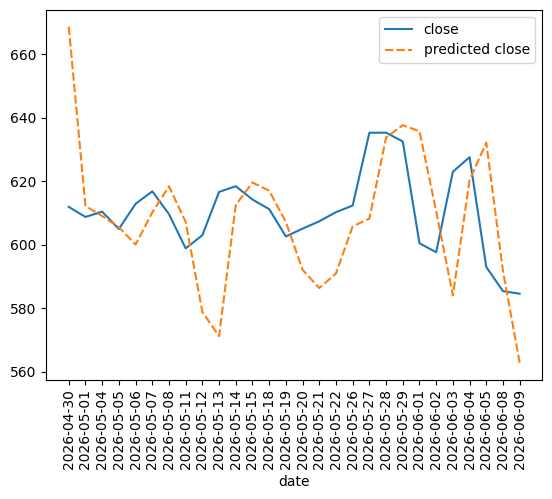

In [20]:
plt.xticks(rotation=90)
sns.lineplot(preds_vs_actual.set_index('date'))